# XGBoost for Manhattan Data

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import TimeSeriesSplit


import xgboost as xgb
from sklearn.metrics import mean_squared_error

color_pal = sns.color_palette()
plt.style.use('fivethirtyeight')

## Setting up the data

In [20]:
df = pd.read_csv('../scr/data/cleaned_rat_sightings_data/daily_borough_rs.csv')
df['created_date'] = pd.to_datetime(df['created_date']) 
df = df[df['borough']=='MANHATTAN']
full_dates = pd.date_range('2020-01-01', '2025-12-31', freq='D')
full_index = pd.MultiIndex.from_product([['MANHATTAN'], full_dates], names=['borough', 'created_date'])
df = df.set_index(['borough', 'created_date']).reindex(full_index).fillna({'count': 0}).reset_index()
df['count'] = df['count'].astype(int)
df.drop(columns=['borough'], inplace=True)
df = df.rename(columns = {'created_date' : 'ds', 'count':'y'})

In [21]:
df = df.set_index('ds')
df.index = pd.to_datetime(df.index)

In [22]:
def create_features(df):
    """
    Create time series features based on time series index.
    """
    df = df.copy()
    df['dayofweek'] = df.index.dayofweek
    df['quarter'] = df.index.quarter
    df['month'] = df.index.month
    df['year'] = df.index.year
    df['dayofyear'] = df.index.dayofyear
    df['dayofmonth'] = df.index.day
    df['weekofyear'] = df.index.isocalendar().week
    return df

df = create_features(df)

In [23]:
def add_lags(df):
    target_map = df['y'].to_dict()
    df['lag1'] = (df.index - pd.Timedelta('1 days')).map(target_map)
    df['lag2'] = (df.index - pd.Timedelta('2 days')).map(target_map)
    df['lag3'] = (df.index - pd.Timedelta('3 days')).map(target_map)
    df['lag4'] = (df.index - pd.Timedelta('4 days')).map(target_map)
    df['lag5'] = (df.index - pd.Timedelta('5 days')).map(target_map)
    df['lag6'] = (df.index - pd.Timedelta('6 days')).map(target_map)
    df['lag7'] = (df.index - pd.Timedelta('7 days')).map(target_map)
    df['lag8'] = (df.index - pd.Timedelta('8 days')).map(target_map)
    df['lag9'] = (df.index - pd.Timedelta('9 days')).map(target_map)
    df['lag10'] = (df.index - pd.Timedelta('10 days')).map(target_map)
    df['lag11'] = (df.index - pd.Timedelta('11 days')).map(target_map)
    df['lag12'] = (df.index - pd.Timedelta('12 days')).map(target_map)
    df['lag13'] = (df.index - pd.Timedelta('13 days')).map(target_map)
    df['lag14'] = (df.index - pd.Timedelta('14 days')).map(target_map)
    return df

def add_seasonal_lags(df):
    target_map = df['y'].to_dict()
    df['lag365'] = (df.index - pd.Timedelta('365 days')).map(target_map)
    df['lag730'] = (df.index - pd.Timedelta('730 days')).map(target_map)
    df['lag1095'] = (df.index - pd.Timedelta('1095 days')).map(target_map)
    df['lag1460'] = (df.index - pd.Timedelta('1460 days')).map(target_map)
    return df

def add_moving_averages(df):
    df = df.copy()
    
    # Ensure sorted by date
    df = df.sort_index()
    
    # Moving averages (using previous values only)
    df['ma7'] = df['y'].shift(1).rolling(window=7).mean()
    df['ma30'] = df['y'].shift(1).rolling(window=30).mean()
    df['ma365'] = df['y'].shift(1).rolling(window=365).mean()
    
    return df


In [24]:
## Add weather data.

import requests
import pandas as pd

lat, lon = 40.7831, -73.9712
start = "2020-01-01"
end   = "2025-12-31"

url = (
    "https://archive-api.open-meteo.com/v1/archive"
    f"?latitude={lat}&longitude={lon}"
    f"&start_date={start}&end_date={end}"
    "&daily=temperature_2m_max,temperature_2m_min,temperature_2m_mean,"
    "apparent_temperature_max,apparent_temperature_min,apparent_temperature_mean,"
    "precipitation_sum,snowfall_sum"
    "&timezone=America/New_York"
)

response = requests.get(url)
data = response.json()

wd = pd.DataFrame(data["daily"])
wd["date"] = pd.to_datetime(wd["time"])
wd = wd.set_index("date")

In [25]:
def add_weather_data(df, wd):
    df = df.copy()
    wd = wd.copy()
    
    # Ensure datetime index
    df.index = pd.to_datetime(df.index)
    wd.index = pd.to_datetime(wd.index)
    
    # Drop unnecessary column
    if "time" in wd.columns:
        wd = wd.drop(columns=["time"])
    
    # Join on date index
    df = df.join(wd, how="left")
    
    return df

In [26]:
from pandas.tseries.holiday import USFederalHolidayCalendar

def add_federal_holidays(df, custom_holidays=None):
    df = df.copy()
    
    # Ensure datetime index
    df.index = pd.to_datetime(df.index)
    
    cal = USFederalHolidayCalendar()
    holidays = cal.holidays(start=df.index.min(), end=df.index.max())
    
    if custom_holidays:
        for d in custom_holidays:
            if len(d) == 5:  # MM-DD format → recurring annually
                years = df.index.year.unique()
                for y in years:
                    holidays = holidays.append(pd.to_datetime([f"{y}-{d}"]))
            else:  # YYYY-MM-DD → one specific date
                holidays = holidays.append(pd.to_datetime([d]))
    
    holidays = holidays.drop_duplicates().sort_values()
    
    df["is_federal_holiday"] = df.index.isin(holidays).astype(int)
    
    return df

In [27]:
def add_law_flag(df, law_name: str, start_date: str):
    # Adds a binary column to indicate when a new law is active.
    df = df.copy()
    
    # Ensure datetime index
    df.index = pd.to_datetime(df.index)
    
    # Convert start_date to datetime
    start_dt = pd.to_datetime(start_date)
    
    # Create binary column: 1 if date >= start_date, else 0
    df[law_name] = (df.index >= start_dt).astype(int)
    
    return df

In [28]:
df = add_lags(df)
df = add_seasonal_lags(df)
df = add_moving_averages(df)
df = add_weather_data(df,wd)
df = add_federal_holidays(df, custom_holidays = ['12-31'])
df = add_law_flag(df, law_name='Trash_Law', start_date = '2024-03-01')
df = add_law_flag(df, law_name = 'New_Trash_Law', start_date = '2024-11-01')
df = add_law_flag(df, law_name='Rat_Mitigation_Zone', start_date = '2023-07-07')
df = add_law_flag(df, law_name='Rat_Czar_Appointed', start_date = '2023-04-12')

## Hyperparameter Tuning

In [34]:
params = {'objective': 'reg:squarederror',
         'eval_metric': 'rmse',
         'booster': 'gbtree',
         'base_score': 3, 
         'n_estimators': 1000, 
        #  'early_stopping_rounds': 100, 
         'min_child_weight': 3, 
         'learning_rate': 0.003,
         'max_depth': 4, 
         'subsample': 0.8, 
         'colsample_bytree': 0.5, 
         'colsample_bylevel': 0.6, 
         'colsample_bynode': 0.9, 
         'reg_alpha': 0.13, 
         'gamma': 2.43, 
         'reg_lambda': 0.001}

### with Optuna

In [35]:
pip install optuna

Note: you may need to restart the kernel to use updated packages.


In [36]:
import optuna
from xgboost import XGBRegressor
from sklearn.metrics import mean_squared_error

In [96]:
# ntss = tss # Use this if you wish to use the same TimeSeriesSplit as the cross validation.
ntss = TimeSeriesSplit(n_splits=14, test_size=14, gap=0) 

df = df.sort_index()

FEATURES = ['dayofyear', 'dayofmonth', 'dayofweek', 'month',
            'lag1', 'lag2','lag3', 'lag4', 'lag5', 'lag6', 'lag7',
            'lag365', 'lag730',
            'ma30',
            'temperature_2m_max', 'temperature_2m_min', 'temperature_2m_mean',
            'precipitation_sum', 'snowfall_sum', 
            'is_federal_holiday',
            'Trash_Law', 'New_Trash_Law', 'Rat_Mitigation_Zone']

TARGET = 'y'


def objective(trial):

    params = {"base_score": trial.suggest_float("base_score", 0.5, 15),
        "n_estimators": 1000,
        "learning_rate": trial.suggest_float("learning_rate", 1e-3, 0.1, log=True),
        # "early_stopping_rounds": 100,
        "max_depth": 5, #trial.suggest_int("max_depth", 1, 10),
        "subsample": trial.suggest_float("subsample", 0.05, 1.0),
        "colsample_bytree": trial.suggest_float("colsample_bytree", 0.05, 1.0),
        "min_child_weight": 15, # trial.suggest_int("min_child_weight", 1, 20),
        'objective': 'reg:squarederror',
        'eval_metric': 'rmse',
        'booster': 'gbtree'
    }

    scores = []

    for fold, (train_idx, val_idx) in enumerate(ntss.split(df)):

        train = df.iloc[train_idx]
        test = df.iloc[val_idx]

        train = create_features(train)
        test = create_features(test)

        X_train = train[FEATURES]
        y_train = train[TARGET]

        X_test = test[FEATURES]
        y_test = test[TARGET]
        

        # Use only if we wish to use early_stopping_rounds

        # split_index_train = int(len(X_train) -14)  # 14 days for validation
        # split_index_train = int(len(y_train) -14)
        # X_train2, X_val = X_train[:split_index_train], X_train[split_index_train:]
        # y_train2, y_val = y_train[:split_index_train], y_train[split_index_train:]
    
        # reg = xgb.XGBRegressor(**params)
        # reg.fit(X_train2, y_train2, eval_set=[(X_val,y_val)], verbose=False)

        reg = xgb.XGBRegressor(**params)
        reg.fit(X_train,y_train, verbose = False)

        y_pred = reg.predict(X_test)

        score = np.sqrt(mean_squared_error(y_test, y_pred))
        scores.append(score)

        trial.report(score, step=fold)
        if trial.should_prune():
            raise optuna.TrialPruned()

    return np.mean(scores)


study = optuna.create_study(direction="minimize")
study.optimize(objective, n_trials=500)

[I 2026-03-03 16:45:43,751] A new study created in memory with name: no-name-be5a89f2-0e38-44fb-83f2-fceba566e049
[I 2026-03-03 16:46:08,309] Trial 0 finished with value: 4.916701833240588 and parameters: {'base_score': 9.948715341883398, 'learning_rate': 0.0010106490190957328, 'subsample': 0.7565366081991722, 'colsample_bytree': 0.627576475653508}. Best is trial 0 with value: 4.916701833240588.
[I 2026-03-03 16:46:29,489] Trial 1 finished with value: 4.885568122760541 and parameters: {'base_score': 5.663968325434682, 'learning_rate': 0.0033997495964865083, 'subsample': 0.7763048889291102, 'colsample_bytree': 0.24482120508109823}. Best is trial 1 with value: 4.885568122760541.
[I 2026-03-03 16:46:47,493] Trial 2 finished with value: 4.873548188208537 and parameters: {'base_score': 6.937425123329389, 'learning_rate': 0.016535319524326107, 'subsample': 0.11830438644188399, 'colsample_bytree': 0.15677412691765819}. Best is trial 2 with value: 4.873548188208537.
[I 2026-03-03 16:47:04,700]

In [97]:
print("Best RMSE:", study.best_value)
print("Best hyperparameters:", study.best_params)

Best RMSE: 4.546666118945217
Best hyperparameters: {'base_score': 0.5441783888004962, 'learning_rate': 0.002446278458563961, 'subsample': 0.8683440915622224, 'colsample_bytree': 0.8830694266285605}


In [98]:
params.update(study.best_params)

## Fitting the model using Tuned Hyperparameters

In [99]:
# Current hyperparameters

params

{'objective': 'reg:squarederror',
 'eval_metric': 'rmse',
 'booster': 'gbtree',
 'base_score': 0.5441783888004962,
 'n_estimators': 1000,
 'min_child_weight': 15,
 'learning_rate': 0.002446278458563961,
 'max_depth': 5,
 'subsample': 0.8683440915622224,
 'colsample_bytree': 0.8830694266285605,
 'colsample_bylevel': 0.6,
 'colsample_bynode': 0.9,
 'reg_alpha': 0.13,
 'gamma': 2.43,
 'reg_lambda': 0.001}

In [100]:
FEATURES = ['dayofyear', 'dayofmonth', 'dayofweek', 'month',
            'lag1', 'lag2','lag3', 'lag4', 'lag5', 'lag6', 'lag7',
            'lag365', 'lag730',
            'ma30',
            'temperature_2m_max', 'temperature_2m_min', 'temperature_2m_mean',
            'precipitation_sum', 'snowfall_sum', 
            'is_federal_holiday',
            'Trash_Law', 'New_Trash_Law', 'Rat_Mitigation_Zone']

TARGET = 'y'

reg = xgb.XGBRegressor(**params)
reg.fit(df[FEATURES], df[TARGET])


,objective,'reg:squarederror'
,base_score,0.5441783888004962
,booster,'gbtree'
,callbacks,None
,colsample_bylevel,0.6
,colsample_bynode,0.9
,colsample_bytree,0.8830694266285605
,device,None
,early_stopping_rounds,None
,enable_categorical,False
,eval_metric,'rmse'


# How does XGB do with predicting the 2026 data?

In [101]:
# Create future dataframe
future = pd.date_range('2026-01-01','2026-02-28', freq='1d')
future_df = pd.DataFrame(index=future)
future_df['isFuture'] = True
df['isFuture'] = False
df_and_future = pd.concat([df, future_df])
df_and_future = create_features(df_and_future)
df_and_future = add_lags(df_and_future)


In [102]:
future_w_features = df_and_future.query('isFuture').copy()

In [103]:
future_w_features['pred'] = reg.predict(future_w_features[FEATURES])

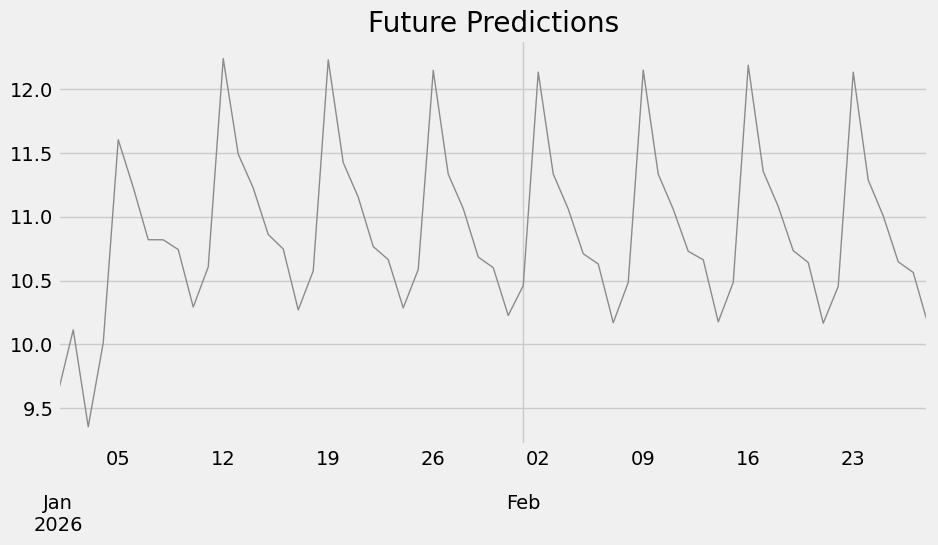

In [104]:
future_w_features['pred'].plot(figsize=(10, 5),
                               color=color_pal[4],
                               ms=1,
                               lw=1,
                               title='Future Predictions')
plt.show()

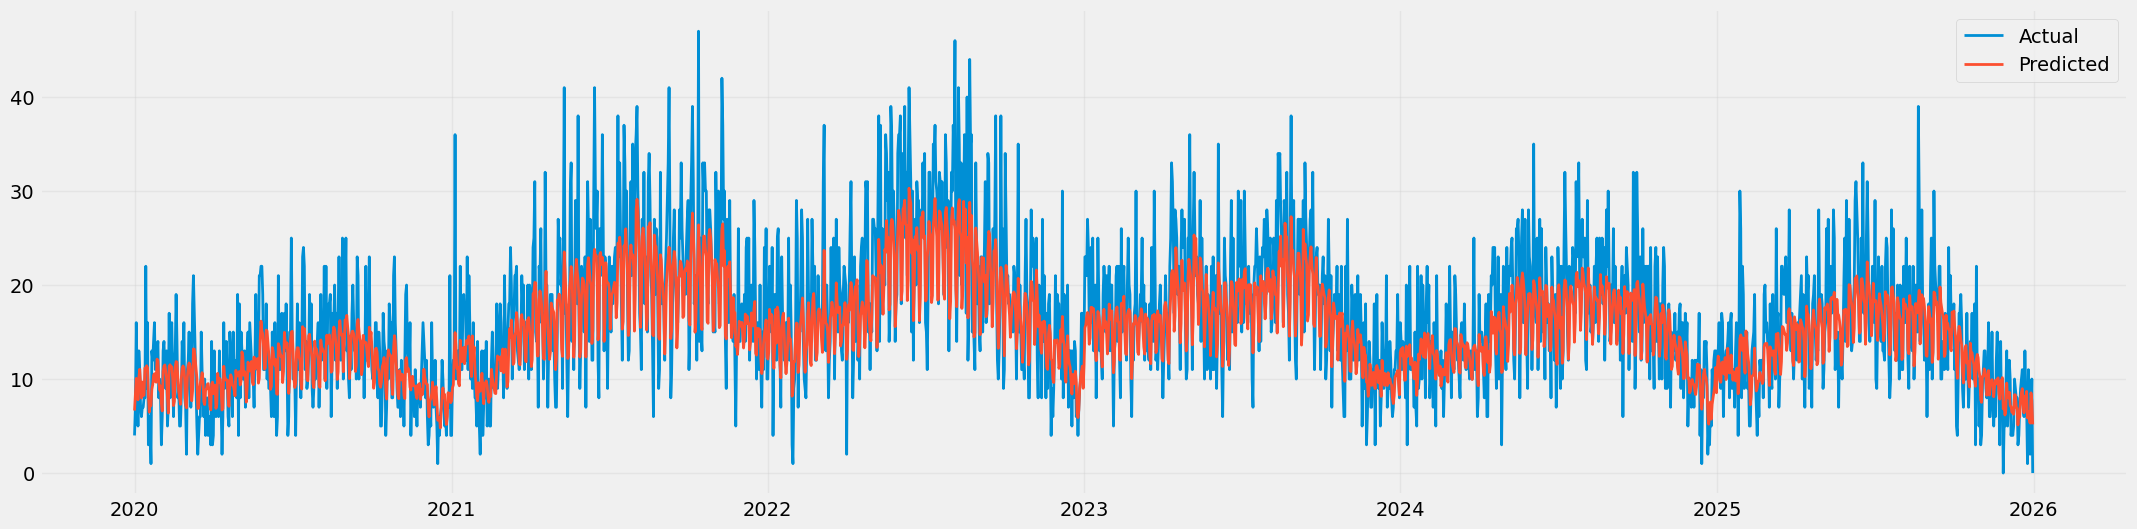

In [105]:
y_pred = reg.predict(df[FEATURES])

plt.figure(figsize=(24,6))
plt.plot(df.index, df[TARGET], label="Actual", linewidth=2)
plt.plot(df.index, y_pred, label="Predicted", linewidth=2)
plt.legend()
plt.grid(alpha=0.3)
plt.show()

In [106]:
print(f"RMSE over the training set {np.sqrt(mean_squared_error(df[TARGET],y_pred))}")

RMSE over the training set 4.7981671012729725


In [107]:
df26 = pd.read_csv('../scr/data/cleaned_rat_sightings_data/daily_borough_rs26.csv')
df26['created_date'] = pd.to_datetime(df26['created_date']) 
df26 = df26[df26['borough']=='MANHATTAN']

full_dates26 = pd.date_range('2026-01-01', '2026-02-28', freq='D')
full_index26 = pd.MultiIndex.from_product([['MANHATTAN'], full_dates26], names=['borough', 'created_date'])

df26 = df26.set_index(['borough', 'created_date']).reindex(full_index26).fillna({'count': 0}).reset_index()
df26['count'] = df26['count'].astype(int)
df26.drop(columns=['borough'], inplace=True)

df26 = df26.rename(columns = {'created_date' : 'ds', 'count':'y'})

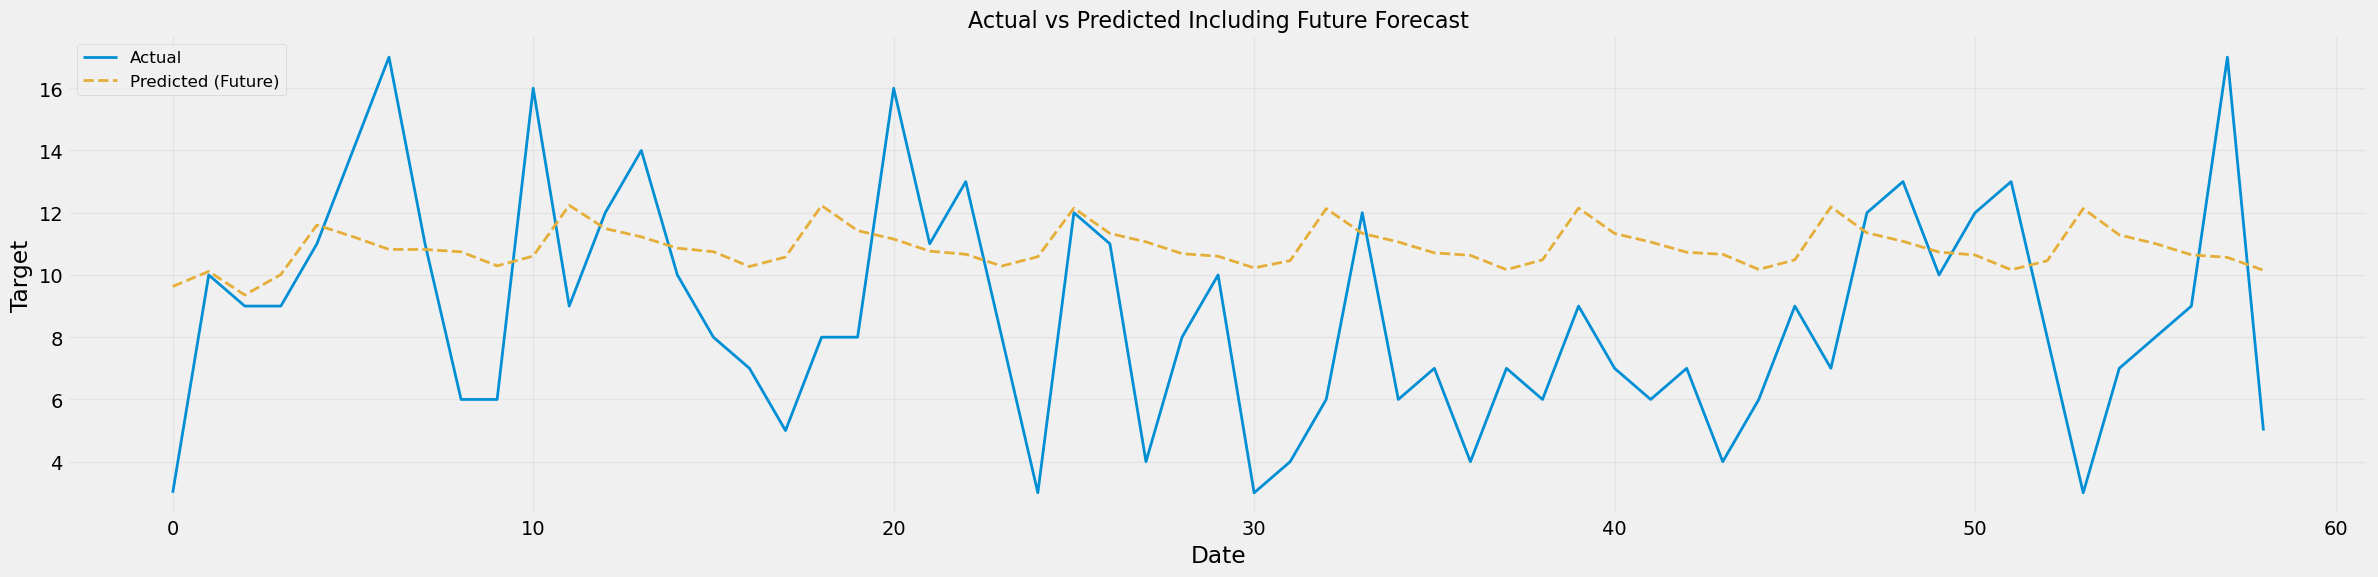

In [108]:
import matplotlib.pyplot as plt

color_pal = plt.rcParams['axes.prop_cycle'].by_key()['color']

plt.figure(figsize=(24,6))

# Plot historical actuals
plt.plot(df26.index, df26['y'].values,
         label="Actual",
         color=color_pal[0],
         linewidth=2)

# Plot future predictions (align index with future_w_features)
plt.plot(df26.index, future_w_features['pred'],
         label="Predicted (Future)",
         color=color_pal[2],
         linewidth=2,
         linestyle='--')  # dashed to distinguish future

# Styling
plt.title("Actual vs Predicted Including Future Forecast", fontsize=16)
plt.xlabel("Date")
plt.ylabel("Target")
plt.legend(fontsize=12)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

In [109]:
rmse = np.sqrt(mean_squared_error(df26['y'], future_w_features['pred']))
print(f"RMSE against actuals: (2026-01-01 to 2026-02-28): {rmse:.4f}")

RMSE against actuals: (2026-01-01 to 2026-02-28): 4.1490
